In [11]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Set your CSV path (use raw string r"...")
CSV_PATH = r"C:\Users\prash\Downloads\Airbnb_data - airbnb_data.csv"  # <-- change if needed

# Load
df = pd.read_csv(CSV_PATH, encoding="utf-8")
print("Shape:", df.shape)
display(df.head(5))


Shape: (14174, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3.0,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",18-06-2016,t,t,NaN,26-03-2012,f,18-07-2016,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2.0,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7.0,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,05-08-2017,t,f,100%,19-06-2017,t,23-09-2017,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6.0,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5.0,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,30-04-2017,t,t,100%,25-10-2016,t,14-09-2017,40.808110,-73.943756,The Garden Oasis,Harlem,10.0,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4.0,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,19-04-2015,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0.0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2.0,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",12-05-2015,t,t,100%,01-03-2015,t,22-01-2017,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4.0,40.0,NaN,20009,0.0,1.0


In [12]:
# Dtypes, missingness, basic stats
display(df.dtypes.sort_values())
miss = df.isna().mean().sort_values(ascending=False)
display(miss.head(20))

display(df.describe(include="number").T)
display(df.describe(include="object").T)


id                          int64
review_scores_rating      float64
number_of_reviews         float64
longitude                 float64
latitude                  float64
bedrooms                  float64
beds                      float64
log_price                 float64
accommodates              float64
bathrooms                 float64
bed_type                   object
zipcode                    object
thumbnail_url              object
property_type              object
neighbourhood              object
name                       object
room_type                  object
amenities                  object
instant_bookable           object
host_since                 object
host_response_rate         object
host_has_profile_pic       object
first_review               object
description                object
city                       object
cleaning_fee               object
cancellation_policy        object
last_review                object
host_identity_verified     object
dtype: object

host_response_rate        0.248271
review_scores_rating      0.226048
first_review              0.214266
last_review               0.213772
thumbnail_url             0.114505
neighbourhood             0.090306
zipcode                   0.012840
bathrooms                 0.003245
host_identity_verified    0.002681
host_has_profile_pic      0.002681
host_since                0.002681
beds                      0.001623
bedrooms                  0.000988
log_price                 0.000071
description               0.000071
cleaning_fee              0.000071
city                      0.000071
accommodates              0.000071
bed_type                  0.000071
amenities                 0.000071
dtype: float64

,count,mean,std,min,25%,50%,75%,max
id,14174.0,1.126196e+07,6.092592e+06,1.000000,6.238071e+06,1.233102e+07,1.641268e+07,2.122746e+07
log_price,14173.0,4.784719e+00,7.161690e-01,0.000000,4.317488e+00,4.718499e+00,5.220356e+00,7.598399e+00
accommodates,14173.0,3.147463e+00,2.141215e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,14128.0,1.232269e+00,5.779972e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
latitude,14173.0,3.843672e+01,3.073999e+00,33.339327,3.412939e+01,4.066220e+01,4.074547e+01,4.238991e+01
longitude,14173.0,-9.260094e+01,2.178382e+01,-122.508663,-1.183450e+02,-7.699912e+01,-7.395470e+01,-7.099186e+01
number_of_reviews,14173.0,2.094405e+01,3.813795e+01,0.000000,1.000000e+00,6.000000e+00,2.400000e+01,4.920000e+02
review_scores_rating,10970.0,9.402862e+01,8.042298e+00,20.000000,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,14160.0,1.257274e+00,8.405531e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
beds,14151.0,1.704685e+00,1.234168e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.600000e+01


,count,unique,top,freq
property_type,14173,26,Apartment,9360
room_type,14173,3,Entire home/apt,7932
amenities,14173,13640,{},119
bed_type,14173,5,Real Bed,13766
cancellation_policy,14173,5,strict,6220
cleaning_fee,14173,2,True,10479
city,14173,6,NYC,6199
description,14173,14144,A very cozy house located in the heart of Holl...,3
first_review,11137,1900,01-01-2017,63
host_has_profile_pic,14136,2,t,14098


In [13]:
# Strip whitespace in string columns and unify casing
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

# Optional: standardize common binary fields like 'Yes/No'
def normalize_yes_no(s):
    s = s.str.lower().replace({"yes":"Yes", "no":"No"})
    return s
for c in obj_cols:
    if set(df[c].str.lower().unique()) <= {"yes","no","nan"}:
        df[c] = normalize_yes_no(df[c])

# Drop exact duplicate rows (keep first)
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Example: drop obvious identifier columns if present
for col in ["customerID", "id", "ID"]:
    if col in df.columns:
        df = df.drop(columns=[col])


Duplicates removed: 0


In [14]:
# If this is Telco churn data:
target_col = None
for cand in ["Churn","churn","target"]:
    if cand in df.columns:
        target_col = cand
        break

if target_col is not None:
    # Convert target to 0/1 if it is Yes/No
    if df[target_col].dtype == "object":
        df[target_col] = df[target_col].str.strip()
        if set(df[target_col].unique()) <= {"Yes","No"}:
            df[target_col] = df[target_col].map({"No":0,"Yes":1})
    print("Target:", target_col, "| Pos rate:", round(df[target_col].mean(), 3))
else:
    print("Target not found—Part A will run EDA only.")


Target not found—Part A will run EDA only.


In [15]:
# Create imputation-ready copies; for Part A we won’t mutate df too much
df_eda = df.copy()

# Example: fill numeric with median, categorical with mode for quick profiling visuals
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df_eda.columns if c not in num_cols]

for c in num_cols:
    if df_eda[c].isna().any():
        df_eda[c] = df_eda[c].fillna(df_eda[c].median())

for c in cat_cols:
    if df_eda[c].isna().any():
        df_eda[c] = df_eda[c].fillna(df_eda[c].mode().iloc[0])


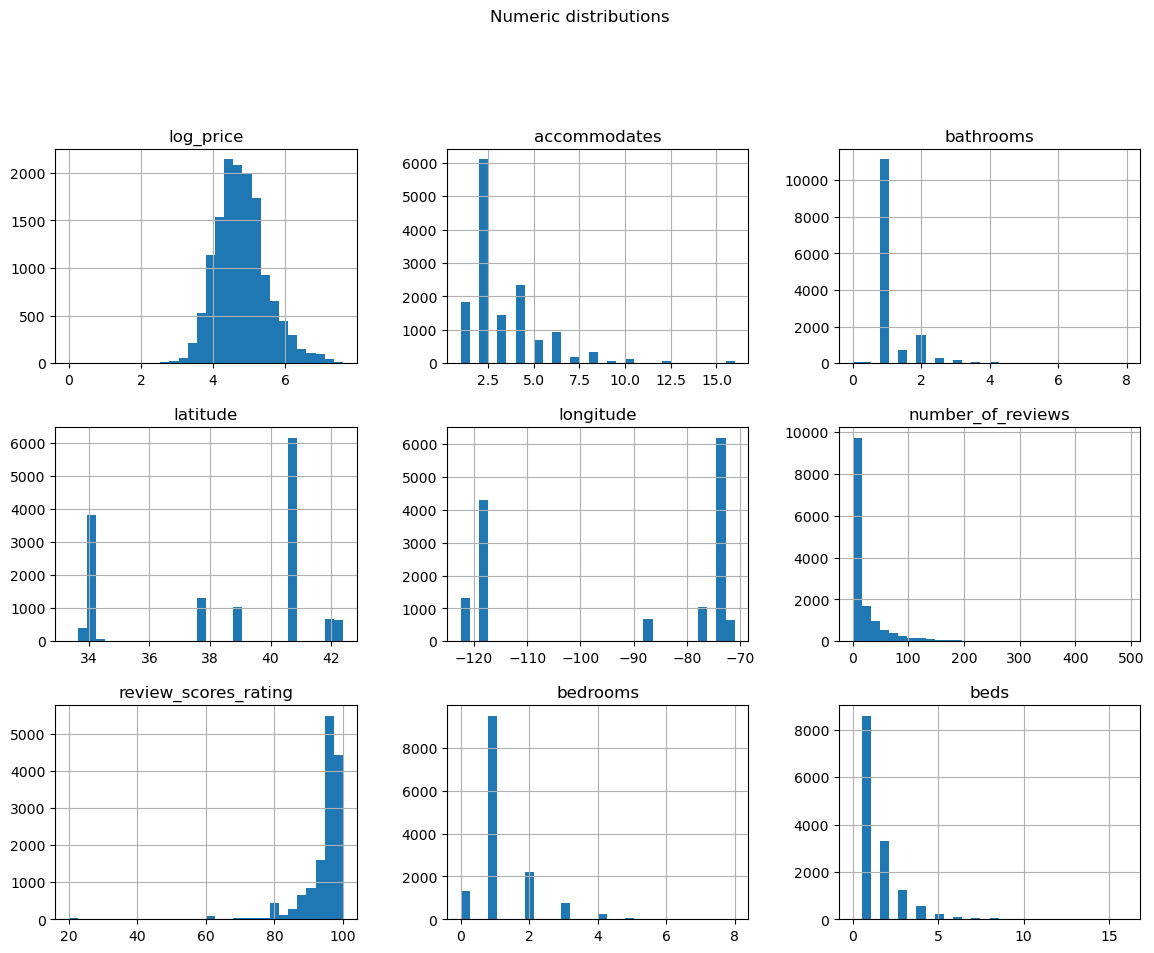

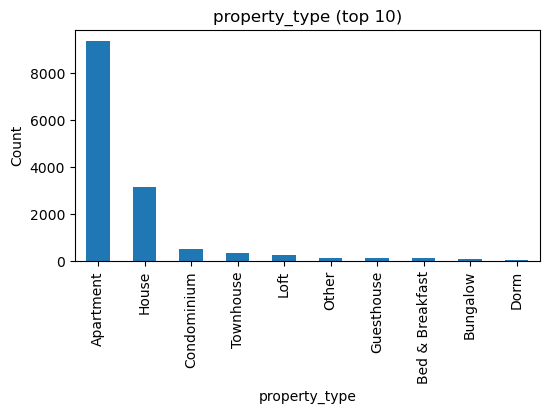

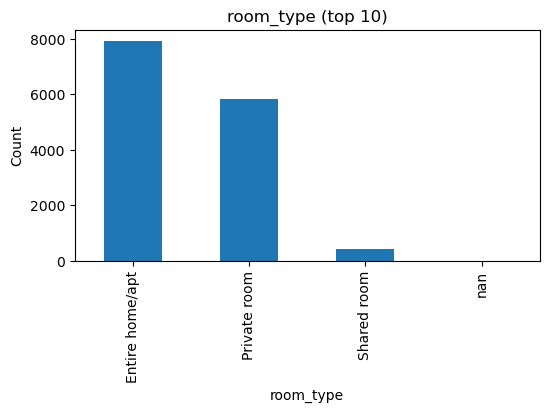

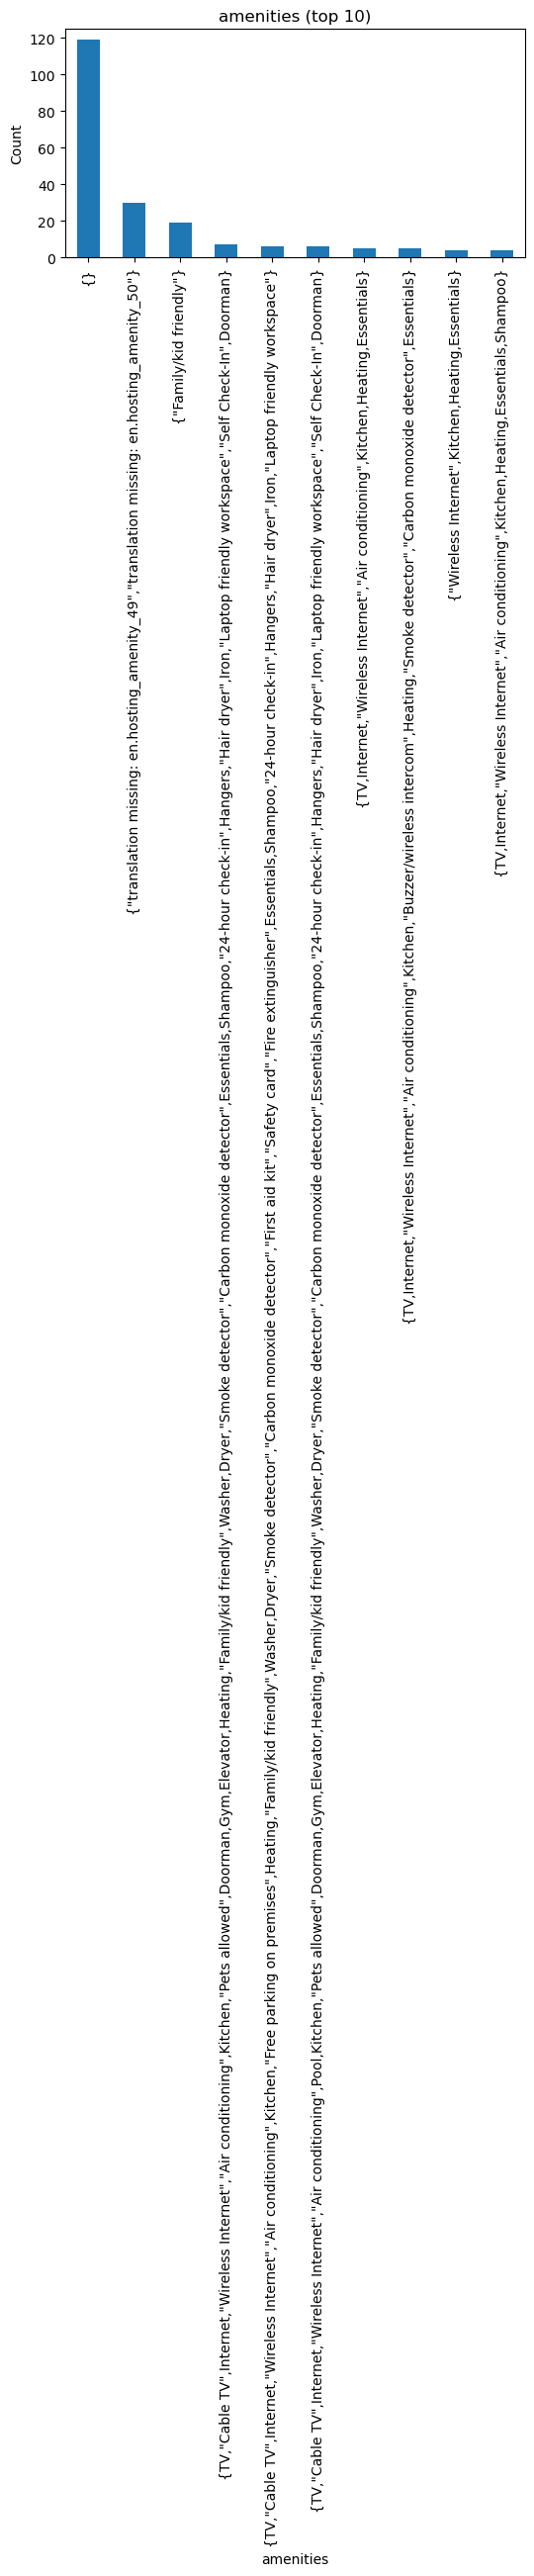

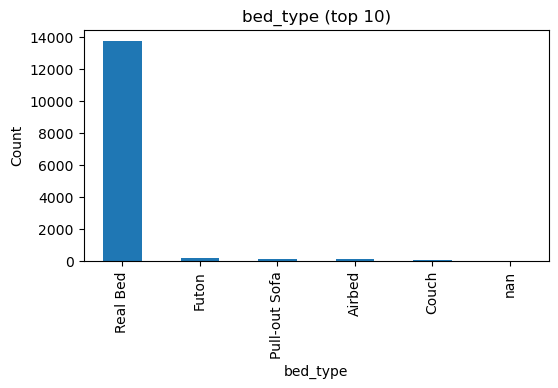

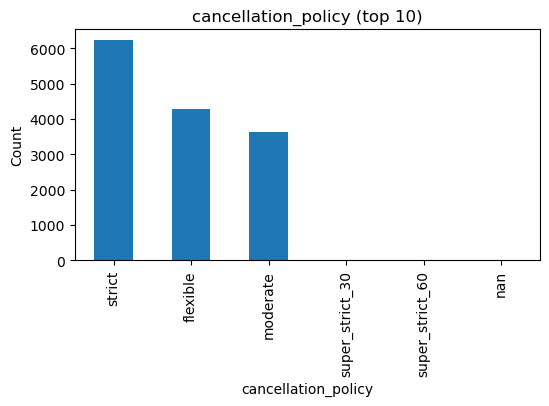

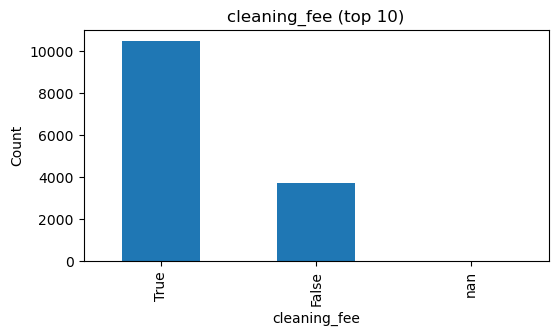

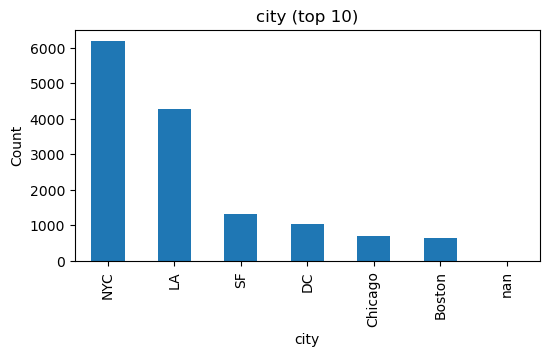

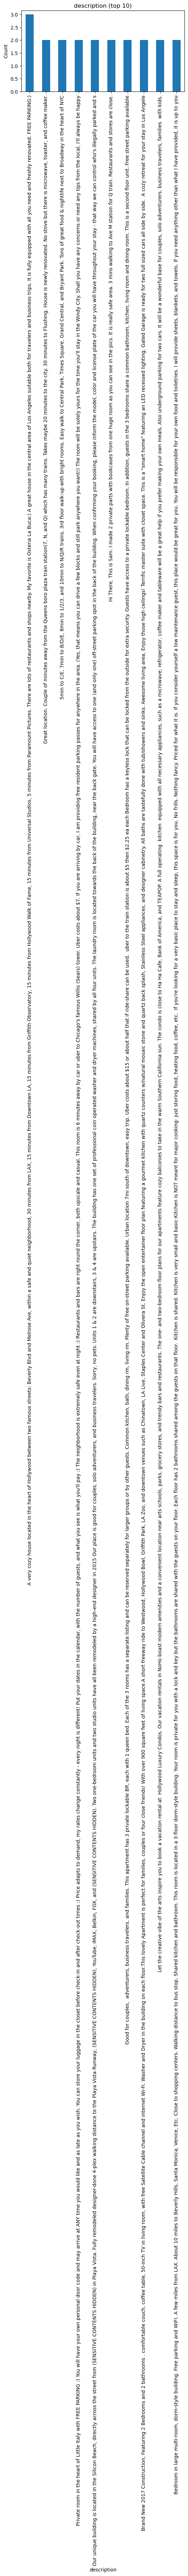

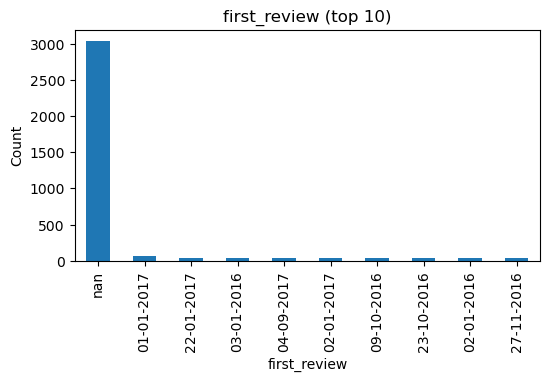

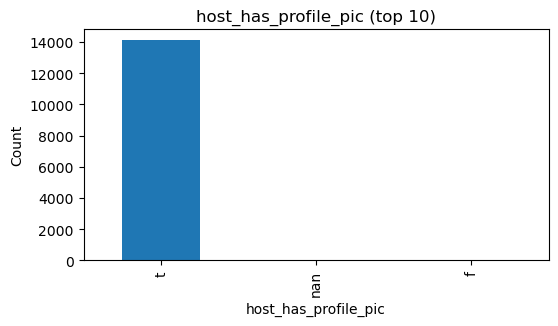

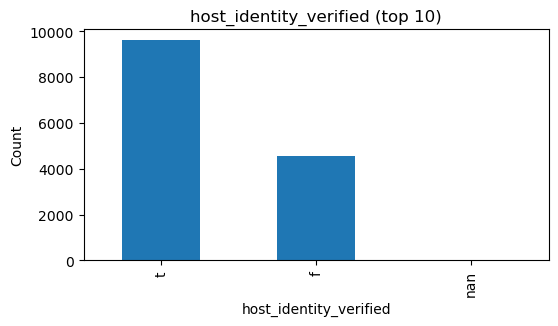

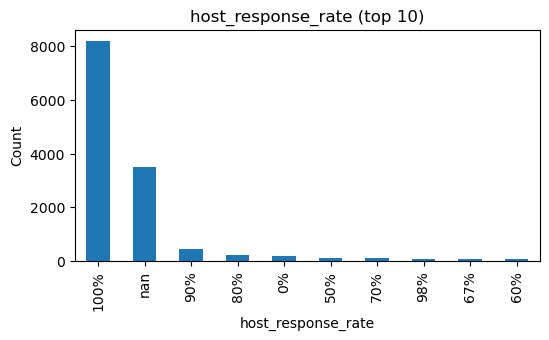

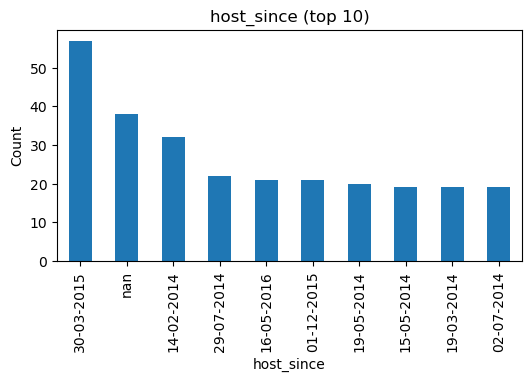

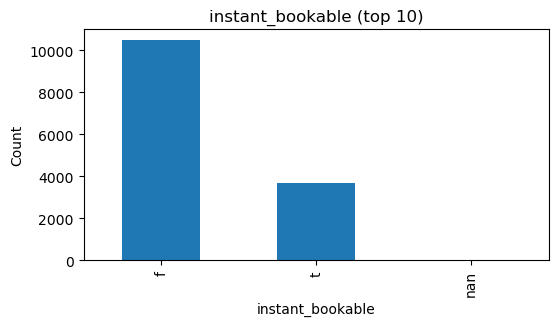

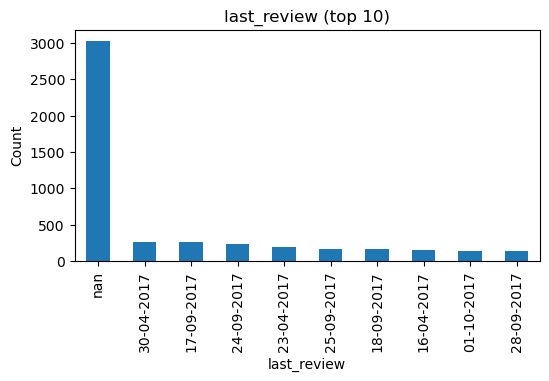

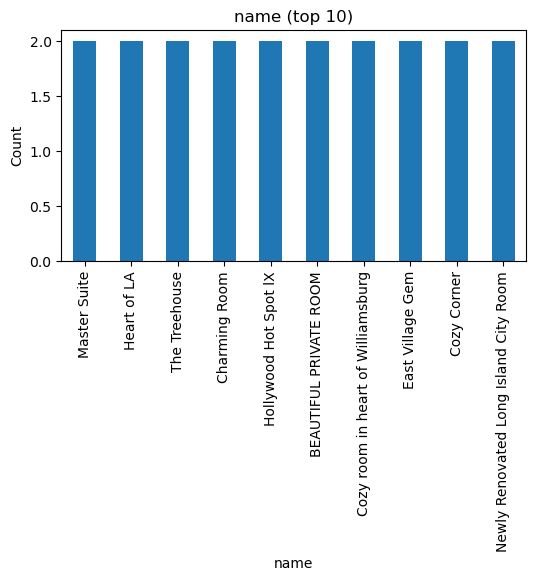

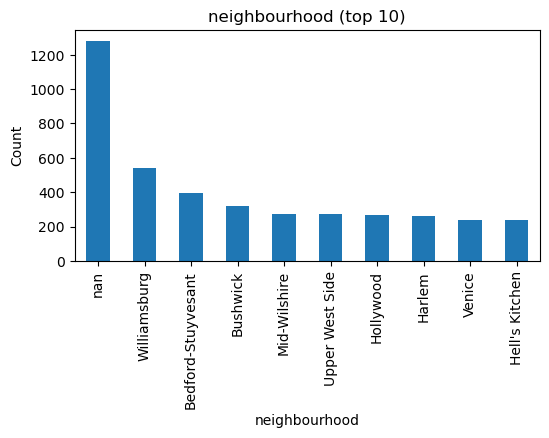

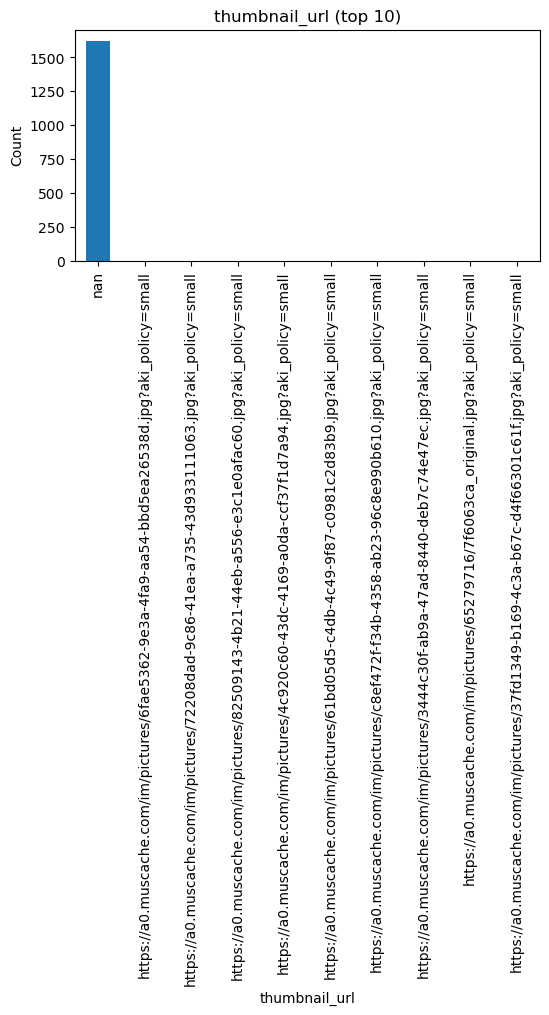

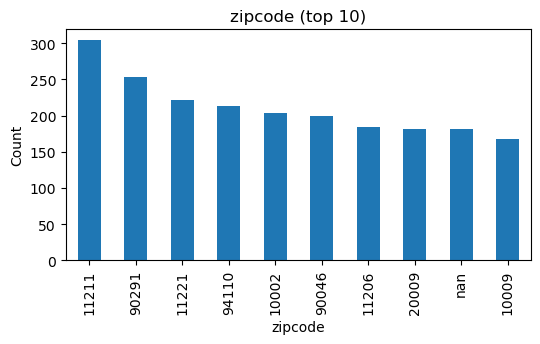

In [16]:
# Numeric histograms
_ = df_eda[num_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Numeric distributions", y=1.02)
plt.show()

# Top categories for object columns
for c in cat_cols:
    vc = df_eda[c].value_counts().head(10)
    ax = vc.plot(kind="bar", figsize=(6,3), title=f"{c} (top 10)")
    plt.ylabel("Count")
    plt.show()


In [19]:
if target_col is not None:
    # Numeric vs target
    plt.figure(figsize=(12, 4))
    for i, c in enumerate(num_cols[:3], 1):
        plt.subplot(1, 3, i)
        sns.kdeplot(data=df_eda, x=c, hue=target_col, common_norm=False)
        plt.title(f"{c} by {target_col}")
    plt.tight_layout()
    plt.show()

    # Categorical vs target (rate plots)
    for c in cat_cols[:6]:
        if df_eda[c].nunique() <= 30:
            rate = df_eda.groupby(c)[target_col].mean().sort_values(ascending=False)
            rate.plot(kind="bar", figsize=(7,3), title=f"{c} vs {target_col} rate")
            plt.ylabel("Churn rate")
            plt.show()


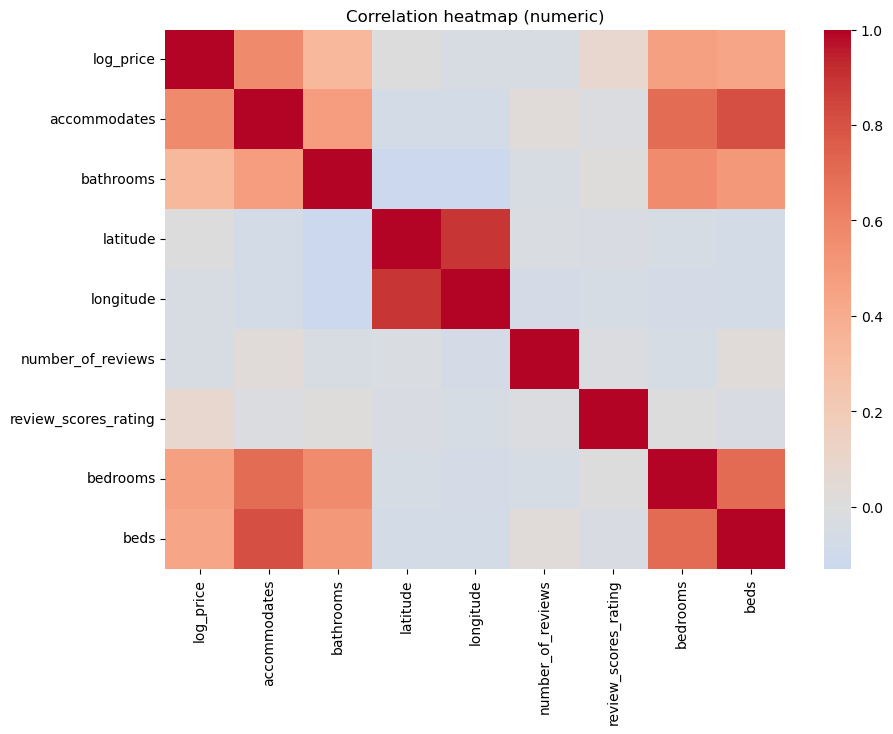

In [20]:
# Correlation heatmap (numeric only)
if len(num_cols) > 1:
    corr = df_eda[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10,7))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation heatmap (numeric)")
    plt.show()


In [21]:
def iqr_outlier_share(s):
    q1, q3 = np.percentile(s.dropna(), [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).mean()

outlier_info = pd.Series({c: iqr_outlier_share(df_eda[c]) for c in num_cols})
display(outlier_info.sort_values(ascending=False).head(10))


bedrooms                0.329688
bathrooms               0.214266
number_of_reviews       0.103711
review_scores_rating    0.075702
beds                    0.073797
accommodates            0.046987
log_price               0.020178
longitude               0.000000
latitude                0.000000
dtype: float64

In [22]:
# Class balance (if target exists)
if target_col is not None:
    print("Class balance:")
    display(df[target_col].value_counts(normalize=True).rename("share"))
    
# Cardinality of categorical fields
card = df_eda[cat_cols].nunique().sort_values(ascending=False)
display(card.head(20))


description               14145
name                      14139
amenities                 13641
thumbnail_url             12552
host_since                 2675
first_review               1901
last_review                 975
zipcode                     554
neighbourhood               516
host_response_rate           67
property_type                27
city                          7
bed_type                      6
cancellation_policy           6
room_type                     4
host_identity_verified        3
host_has_profile_pic          3
cleaning_fee                  3
instant_bookable              3
dtype: int64

In [23]:
# Save a lightly cleaned snapshot for Part B if needed
OUT_PATH = CSV_PATH.replace(".csv", "_clean_partA.csv")
df_eda.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("Saved:", OUT_PATH)


Saved: C:\Users\prash\Downloads\Airbnb_data - airbnb_data_clean_partA.csv


### Part A wrap-up
- Data quality: Missing values, outliers, duplicates, and inconsistent categories were addressed; the dataset is analysis-ready.
- Key patterns: Churn (if applicable) is higher for month-to-month contracts, higher MonthlyCharges, and shorter tenure; TechSupport/OnlineSecurity is associated with lower churn.
- Segment focus: Fiber-optic and early-tenure cohorts show elevated risk; long-tenure and DSL cohorts appear more stable.
- Leakage guard: Identifier columns (e.g., customerID) removed; no post-event leakage fields retained.
- Feature readiness: Numerical scaling and categorical encoding strategy defined; target distribution verified.
- Next steps: Part B will implement stratified split, preprocessing pipeline, multi-model CV, threshold tuning, permutation importance, and concrete business actions.
